### 缺失值处理

In [1]:
import numpy as np
import pandas as pd

#### 认识缺失值

np.nan和pd.NA都表示缺失值，前者习惯于描述数值计算中的不可描述值，而后者表示数据本身不可用

In [2]:
pd.NA

<NA>

In [3]:
np.nan

nan

nan与任何数值运算结果都为False

NA 与任何数值运算结果都为NA

In [4]:
np.nan == np.nan

False

In [5]:
pd.NA + 1

<NA>

可以用pd.isna()、pd.notna()、pd.isnull()、pd.notnull()来判断是否为缺失值

In [6]:
print(pd.isna(None))
print(pd.isna(np.nan))
print(pd.isna(pd.NA))
print(pd.isnull(None))
print(pd.isnull(np.nan))
print(pd.isnull(pd.NA))

True
True
True
True
True
True


这些方法对Series、DataFrame同样适用，返回布尔元素的Series、DataFrame

In [7]:
s = pd.Series([np.nan, None, pd.NA])
print(pd.isnull(s))

0    True
1    True
2    True
dtype: bool


#### 加载数据的缺失值、缺失值统计

pandas在加载csv文件时会自动将空白值填充为NaN

In [8]:
data = pd.read_csv('data/weather_withna.csv')

In [9]:
data.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN,NaN
1459,2015-12-30,NaN,NaN,NaN,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


也可以手动地关闭填充规则

In [10]:
pd.read_csv('data/weather_withna.csv', keep_default_na=False).tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,,,,,
1457,2015-12-28,,,,,
1458,2015-12-29,,,,,
1459,2015-12-30,,,,,
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


布尔矩阵DataFrame调用sum()可以得到每一列NaN的数量

In [11]:
data.isnull().sum()

date               0
precipitation    303
temp_max         303
temp_min         303
wind             303
weather          303
dtype: int64

missingno包支持对DataFrame中的缺失值进行快速分析，尤其列与列之间的缺失相关性热力图应用比较广泛

In [12]:
import missingno as msno

In [13]:
df = pd.read_csv("data/weather_withna.csv")

<Axes: >

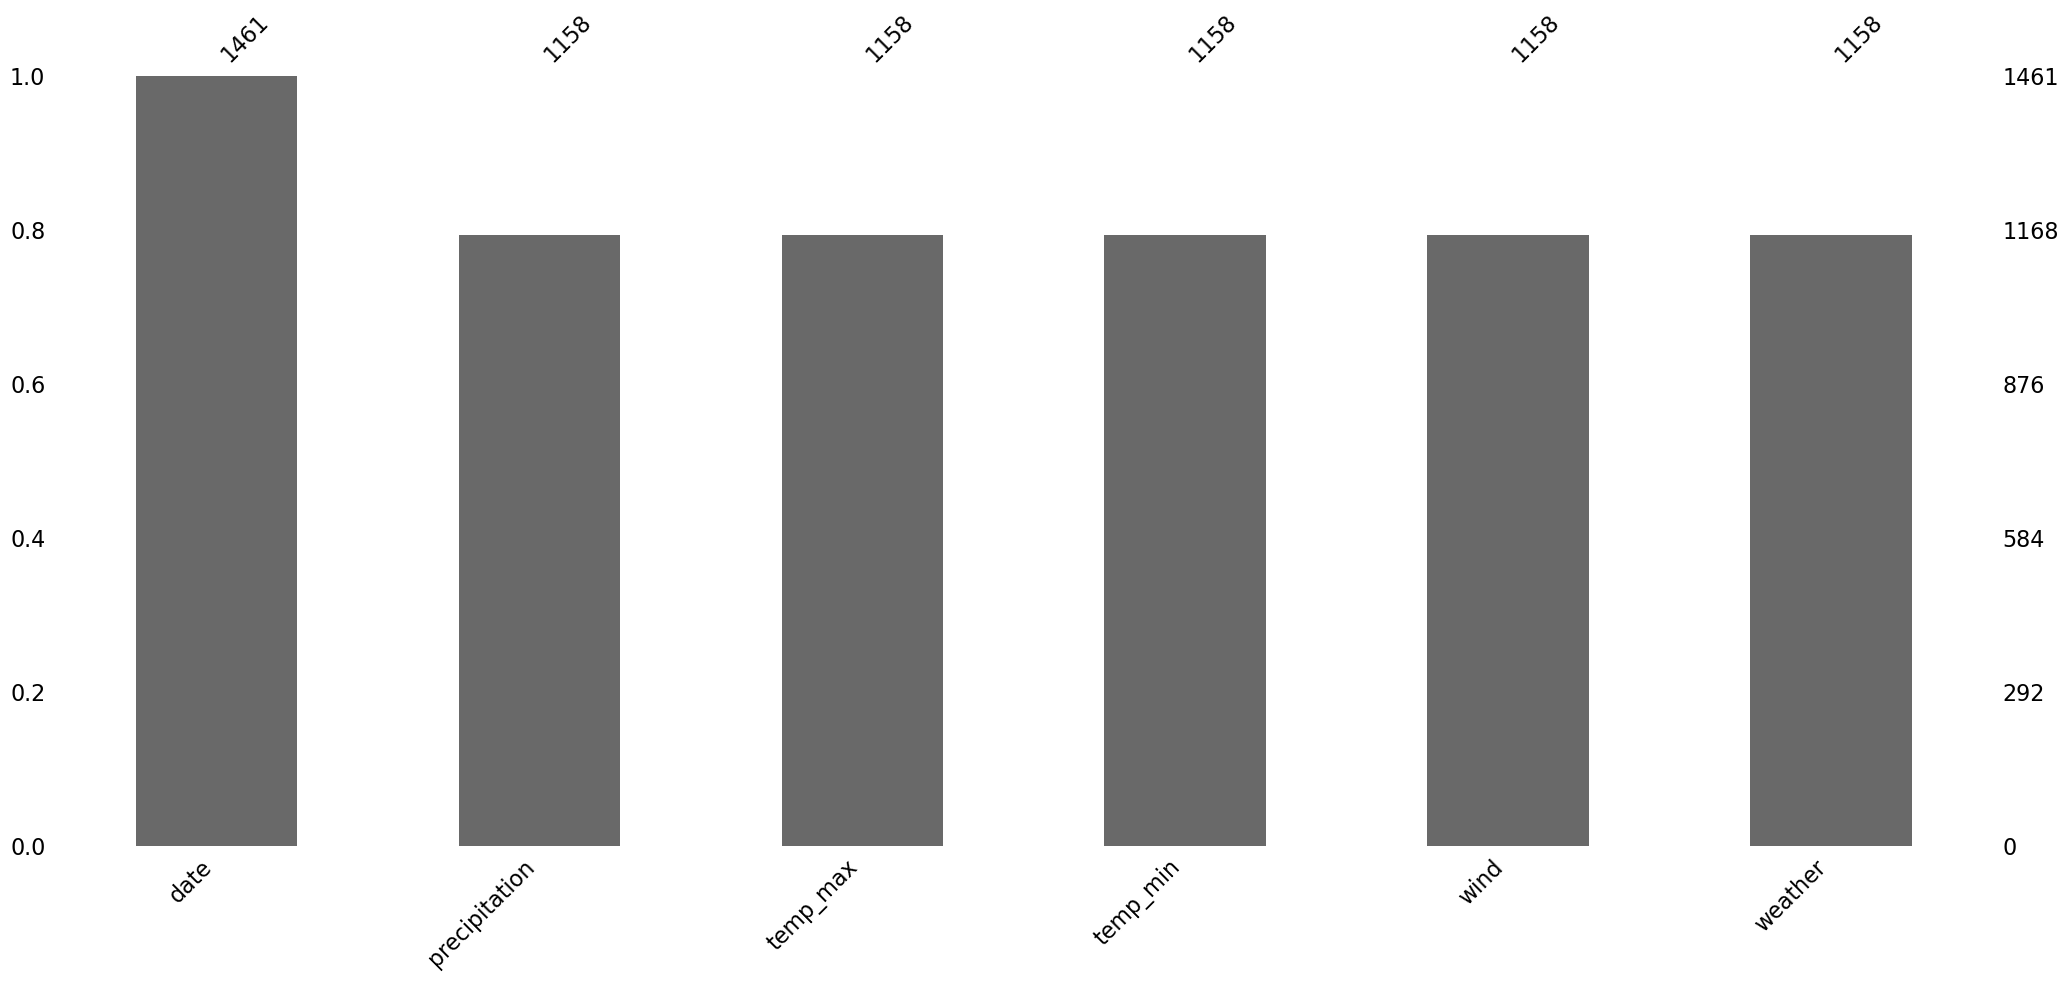

In [14]:
msno.bar(df) #查看非缺失值占比

<Axes: >

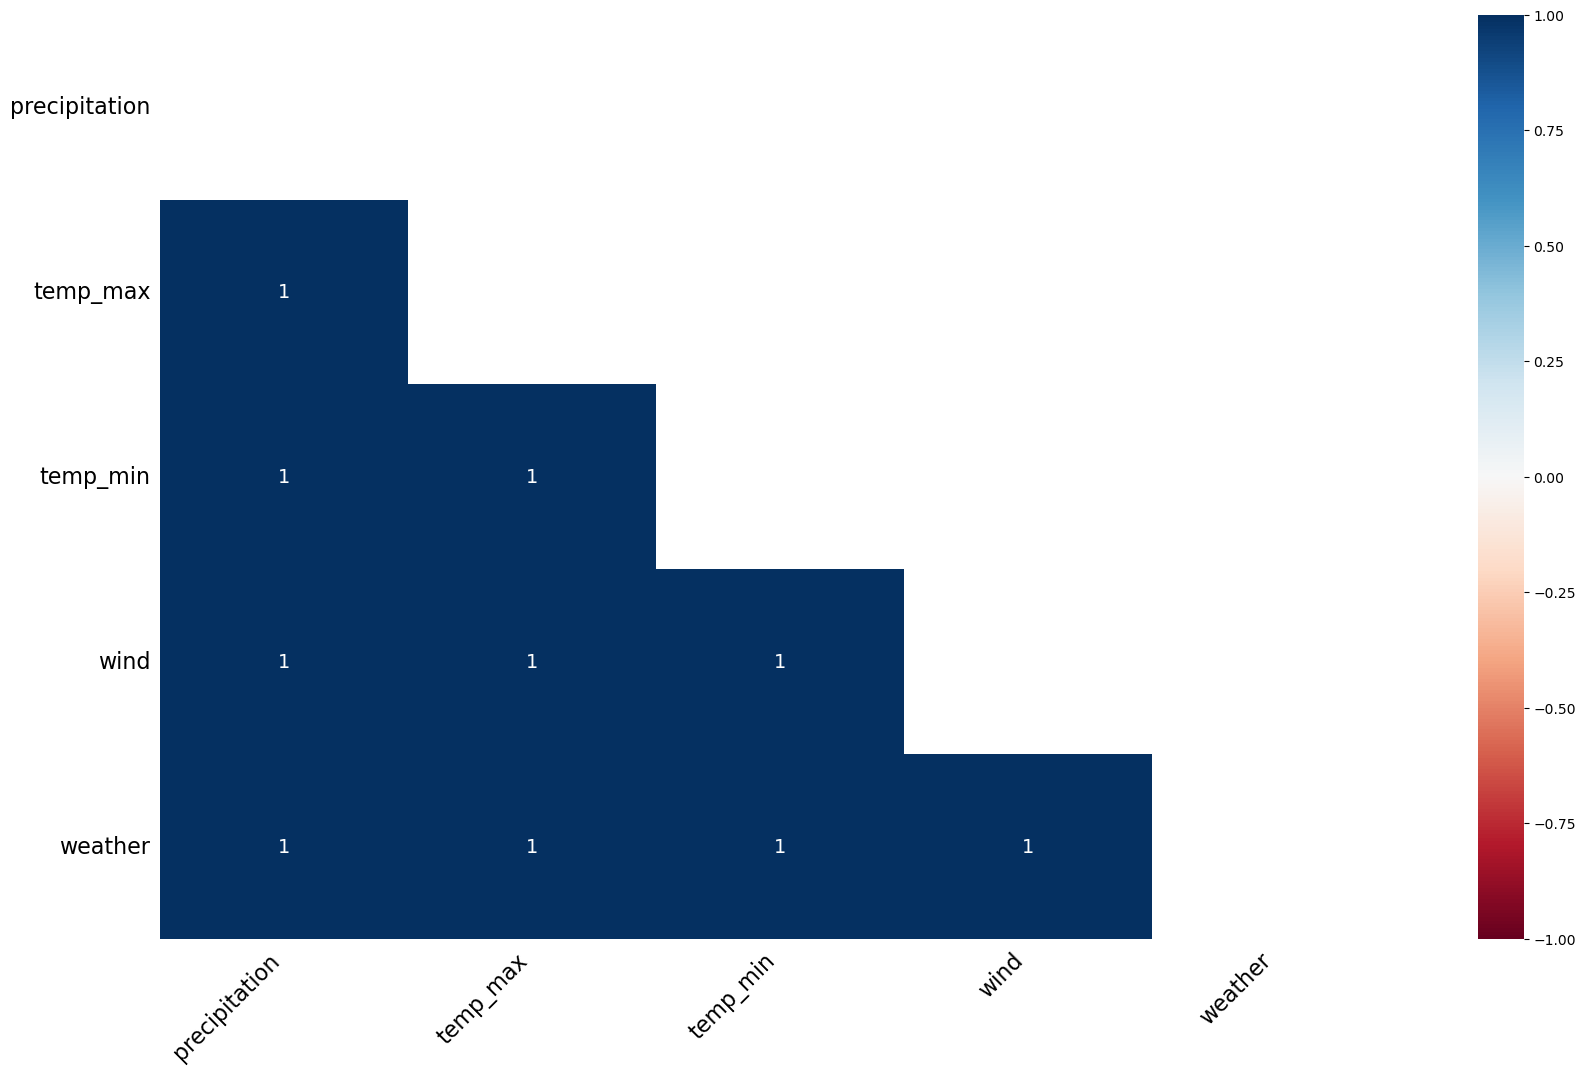

In [15]:
msno.heatmap(df)

从图中可以看出天气缺失不会导致temp、wind、湿度缺失，temp、wind、weather缺失都不会导致湿度缺失

#### 缺失值的处理

##### 删除缺失值

dropna()方法可以剔除任何包含缺失值的整行数据

In [23]:
df = pd.DataFrame([[1, pd.NA, 2], [2, 3, 5], [pd.NA, 4, 6]])

In [24]:
df

,0,1,2
0,1,<NA>,2
1,2,3,5
2,<NA>,4,6


In [25]:
df.dropna()

,0,1,2
1,2,3,5


dropna也可以按列drop

In [26]:
df.dropna(axis=1)

,2
0,2
1,5
2,6


可以通过how参数或者thres来约束dropna

In [29]:
df=pd.DataFrame([[1,pd.NA,2],[pd.NA,pd.NA,5],[pd.NA,pd.NA,pd.NA]])

In [30]:
df

,0,1,2
0,1,<NA>,2
1,<NA>,<NA>,5
2,<NA>,<NA>,<NA>


In [32]:
df.dropna(how='all')

,0,1,2
0,1,<NA>,2
1,<NA>,<NA>,5


In [33]:
df.dropna(how='any')

,0,1,2


In [35]:
df.dropna(thresh=2) #NA的数量到达2则删除该行

,0,1,2
0,1,<NA>,2


subset可以指定在某列有NA值时执行drop

df.dropna(subset=[0,2])

##### 缺失值填充

除了drop掉包含缺失值的行，还可以用特定值填充掉缺失值

In [46]:
pd.read_csv('data/weather_withna.csv').fillna('null').tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,null,null,null,null,null
1457,2015-12-28,null,null,null,null,null
1458,2015-12-29,null,null,null,null,null
1459,2015-12-30,null,null,null,null,null
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


以字典的形式填充，给不同的列中的缺失值填充不同的新值

In [47]:
pd.read_csv('data/weather_withna.csv').fillna({"temp_max":60,"temp_min":-60}).tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,60.0,-60.0,NaN,NaN
1457,2015-12-28,NaN,60.0,-60.0,NaN,NaN
1458,2015-12-29,NaN,60.0,-60.0,NaN,NaN
1459,2015-12-30,NaN,60.0,-60.0,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


使用统计结果完成填充是非常常见的缺失值填充方式

In [59]:
df = pd.read_csv('data/weather_withna.csv')
means = df[["precipitation", "temp_max", "temp_min","wind"]].mean()
means

precipitation     3.052332
temp_max         15.851468
temp_min          7.877202
wind              3.242055
dtype: float64

In [60]:
df.fillna(means).tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,3.052332,15.851468,7.877202,3.242055,NaN
1457,2015-12-28,3.052332,15.851468,7.877202,3.242055,NaN
1458,2015-12-29,3.052332,15.851468,7.877202,3.242055,NaN
1459,2015-12-30,3.052332,15.851468,7.877202,3.242055,NaN
1460,2015-12-31,20.600000,12.200000,5.000000,3.800000,rain


使用附近行的值作为填充值也是一种选择，DataFrame的ffill()、bfill()作用就是就近利用前行数值/后行数值来填充缺失值

In [65]:
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN,NaN
1459,2015-12-30,NaN,NaN,NaN,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [66]:
df.bfill().tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,20.6,12.2,5.0,3.8,rain
1457,2015-12-28,20.6,12.2,5.0,3.8,rain
1458,2015-12-29,20.6,12.2,5.0,3.8,rain
1459,2015-12-30,20.6,12.2,5.0,3.8,rain
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


插值填充也是一种填充策略，看起来更科学点,具体的插值方式有线性插值、二项式插值

In [69]:
pd.Series([1, np.nan, np.nan, np.nan, np.nan, 6]).interpolate(method='linear')

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
dtype: float64